<a href="https://colab.research.google.com/github/HarishKL01/Simplilearn-Capstone/blob/main/Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#importing datasets into GDrive
df_items= pd.read_csv('/content/drive/MyDrive/Projectdataset/items.csv')
df_restraunts= pd.read_csv('/content/drive/MyDrive/Projectdataset/resturants.csv')
df_sales= pd.read_csv('/content/drive/MyDrive/Projectdataset/sales.csv')


In [ ]:
#Preliminary analysis
#shape and structure of items.csv
print(f"Dataset shape: {df_items.shape}\n")
display(df_items.info())
display(df_items.describe())
display(df_items.head())
display(df_items.isnull().sum())

Dataset shape: (100, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        100 non-null    int64  
 1   store_id  100 non-null    int64  
 2   name      100 non-null    object 
 3   kcal      100 non-null    int64  
 4   cost      100 non-null    float64
dtypes: float64(1), int64(3), object(1)
memory usage: 4.0+ KB


None

,id,store_id,kcal,cost
count,100.000000,100.000000,100.000000,100.000000
mean,50.500000,3.520000,536.730000,11.763700
std,29.011492,1.708446,202.212852,8.991254
min,1.000000,1.000000,78.000000,1.390000
25%,25.750000,2.000000,406.250000,5.280000
50%,50.500000,4.000000,572.500000,7.625000
75%,75.250000,5.000000,638.250000,18.790000
max,100.000000,6.000000,1023.000000,53.980000


,id,store_id,name,kcal,cost
0,1,4,Chocolate Cake,554,6.71
1,2,4,Breaded Fish with Vegetables Meal,772,15.09
2,3,1,Sweet Fruity Cake,931,29.22
3,4,1,Amazing Steak Dinner with Rolls,763,26.42
4,5,5,Milk Cake,583,6.07


,0
id,0
store_id,0
name,0
kcal,0
cost,0


In [ ]:
#finding outliers in items.csv
num_cols =["kcal", "cost"]

for col in num_cols:
    q1 = df_items[col].quantile(0.25)
    q3 = df_items[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df_items[(df_items[col] < lower) | (df_items[col] > upper)]

    print("\nOutliers in", col)
    print(outliers[["id", "store_id", "name", col]])


Outliers in kcal
    id  store_id                                          name  kcal
32  33         6  Original Breaded Pork with Vegetables Dinner  1023

Outliers in cost
    id  store_id                           name   cost
79  80         4  Blue Ribbon Fruity Vegi Lunch  53.98


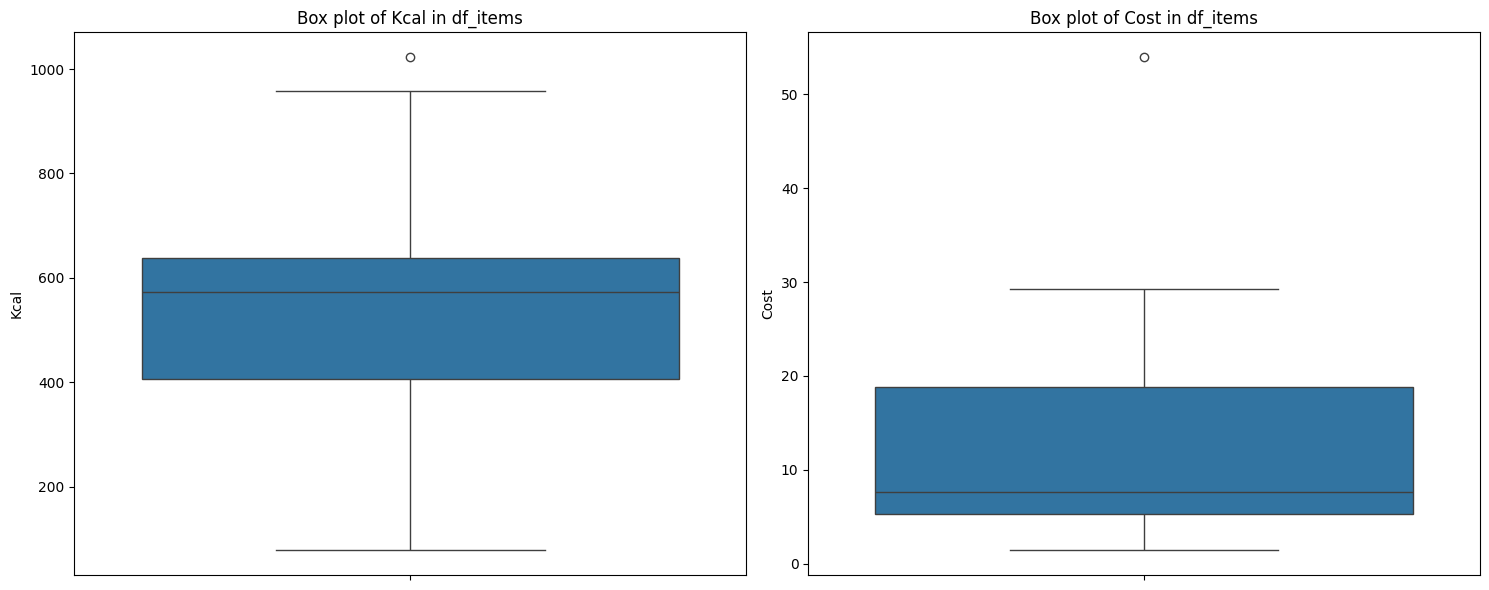

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(ax=axes[0], y=df_items['kcal'])
axes[0].set_title('Box plot of Kcal in df_items')
axes[0].set_ylabel('Kcal')

sns.boxplot(ax=axes[1], y=df_items['cost'])
axes[1].set_title('Box plot of Cost in df_items')
axes[1].set_ylabel('Cost')

plt.tight_layout()
plt.show()


In [ ]:
#shape and structure of restraunts.csv
print(f"Dataset shape: {df_restraunts.shape}\n")
display(df_restraunts.info())
display(df_restraunts.describe())
display(df_restraunts.head())
display(df_restraunts.isnull().sum())

Dataset shape: (6, 2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      6 non-null      int64 
 1   name    6 non-null      object
dtypes: int64(1), object(1)
memory usage: 228.0+ bytes


None

,id
count,6.000000
mean,3.500000
std,1.870829
min,1.000000
25%,2.250000
50%,3.500000
75%,4.750000
max,6.000000


,id,name
0,1,Bob's Diner
1,2,Beachfront Bar
2,3,Sweet Shack
3,4,Fou Cher
4,5,Corner Cafe


,0
id,0
name,0


In [ ]:
#finding outliers in restraunts.csv
# restraunts.csv is list of restraunts finding outliers may not be necessary
num_cols = df_restraunts.select_dtypes(include="number").columns

for col in num_cols:
    q1 = df_restraunts[col].quantile(0.25)
    q3 = df_restraunts[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df_restraunts[(df_restraunts[col] < lower) | (df_restraunts[col] > upper)]

    print("\nOutliers in", col)
    print(outliers)


Outliers in id
Empty DataFrame
Columns: [id, name]
Index: []


In [ ]:
#shape and structure of sales.csv
print(f"Dataset shape: {df_sales.shape}\n")
display(df_sales.info())
display(df_sales.describe())
display(df_sales.head())
display(df_sales.isnull().sum())

Dataset shape: (109600, 4)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109600 entries, 0 to 109599
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   date        109600 non-null  object 
 1   item_id     109600 non-null  int64  
 2   price       109600 non-null  float64
 3   item_count  109600 non-null  float64
dtypes: float64(2), int64(1), object(1)
memory usage: 3.3+ MB


None

,item_id,price,item_count
count,109600.000000,109600.000000,109600.000000
mean,50.500000,11.763700,6.339297
std,28.866202,8.946225,30.003728
min,1.000000,1.390000,0.000000
25%,25.750000,5.280000,0.000000
50%,50.500000,7.625000,0.000000
75%,75.250000,18.790000,0.000000
max,100.000000,53.980000,570.000000


,date,item_id,price,item_count
0,2019-01-01,3,29.22,2.0
1,2019-01-01,4,26.42,22.0
2,2019-01-01,12,4.87,7.0
3,2019-01-01,13,4.18,12.0
4,2019-01-01,16,3.21,136.0


,0
date,0
item_id,0
price,0
item_count,0


In [ ]:
#finding outliers in sales.csv
num_cols = df_sales.select_dtypes(include="number").columns

for col in num_cols:
    q1 = df_sales[col].quantile(0.25)
    q3 = df_sales[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df_sales[(df_sales[col] < lower) | (df_sales[col] > upper)]

    print("\nOutliers in", col)
    print(outliers)


Outliers in item_id
Empty DataFrame
Columns: [date, item_id, price, item_count]
Index: []

Outliers in price
              date  item_id  price  item_count
82      2019-01-01       80  53.98         0.0
115     2019-01-02       80  53.98         2.0
216     2019-01-03       80  53.98         2.0
316     2019-01-04       80  53.98         1.0
482     2019-01-05       80  53.98         0.0
...            ...      ...    ...         ...
109119  2021-12-27       80  53.98         1.0
109280  2021-12-28       80  53.98         0.0
109379  2021-12-29       80  53.98         0.0
109480  2021-12-30       80  53.98         0.0
109580  2021-12-31       80  53.98         0.0

[1096 rows x 4 columns]

Outliers in item_count
              date  item_id  price  item_count
0       2019-01-01        3  29.22         2.0
1       2019-01-01        4  26.42        22.0
2       2019-01-01       12   4.87         7.0
3       2019-01-01       13   4.18        12.0
4       2019-01-01       16   3.21       1

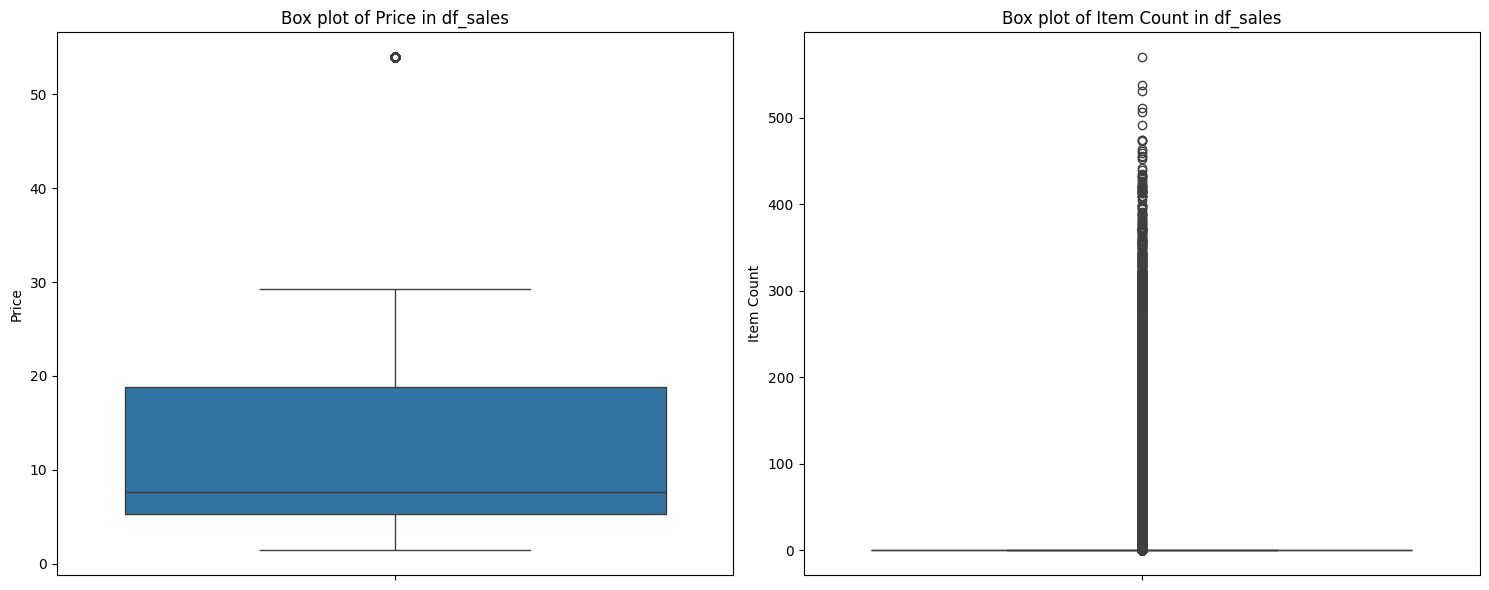

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(ax=axes[0], y=df_sales['price'])
axes[0].set_title('Box plot of Price in df_sales')
axes[0].set_ylabel('Price')

sns.boxplot(ax=axes[1], y=df_sales['item_count'])
axes[1].set_title('Box plot of Item Count in df_sales')
axes[1].set_ylabel('Item Count')

plt.tight_layout()
plt.show()

In [ ]:
df = df_sales.merge(df_items, left_on="item_id", right_on="id", how="left")
df


,date,item_id,price,item_count,id,store_id,name,kcal,cost
0,2019-01-01,3,29.22,2.0,3,1,Sweet Fruity Cake,931,29.22
1,2019-01-01,4,26.42,22.0,4,1,Amazing Steak Dinner with Rolls,763,26.42
2,2019-01-01,12,4.87,7.0,12,1,Fantastic Sweet Cola,478,4.87
3,2019-01-01,13,4.18,12.0,13,1,Sweet Frozen Soft Drink,490,4.18
4,2019-01-01,16,3.21,136.0,16,1,Frozen Milky Smoothy,284,3.21
...,...,...,...,...,...,...,...,...,...
109595,2021-12-31,96,21.93,0.0,96,5,Blue Ribbon Fish with Bread Lunch,708,21.93
109596,2021-12-31,97,28.65,0.0,97,4,Original Fruity Cod with Bread and Vegetables ...,744,28.65
109597,2021-12-31,98,5.00,0.0,98,2,Original Sweet Milky Soft Drink,579,5.00
109598,2021-12-31,99,5.32,0.0,99,4,Frozen Tomato Soft Drink,423,5.32


In [ ]:
df = df.merge(df_restraunts, left_on="store_id", right_on ="id", how="left")
df

,date,item_id,price,item_count,id_x,store_id,name_x,kcal,cost,id_y,name_y
0,2019-01-01,3,29.22,2.0,3,1,Sweet Fruity Cake,931,29.22,1,Bob's Diner
1,2019-01-01,4,26.42,22.0,4,1,Amazing Steak Dinner with Rolls,763,26.42,1,Bob's Diner
2,2019-01-01,12,4.87,7.0,12,1,Fantastic Sweet Cola,478,4.87,1,Bob's Diner
3,2019-01-01,13,4.18,12.0,13,1,Sweet Frozen Soft Drink,490,4.18,1,Bob's Diner
4,2019-01-01,16,3.21,136.0,16,1,Frozen Milky Smoothy,284,3.21,1,Bob's Diner
...,...,...,...,...,...,...,...,...,...,...,...
109595,2021-12-31,96,21.93,0.0,96,5,Blue Ribbon Fish with Bread Lunch,708,21.93,5,Corner Cafe
109596,2021-12-31,97,28.65,0.0,97,4,Original Fruity Cod with Bread and Vegetables ...,744,28.65,4,Fou Cher
109597,2021-12-31,98,5.00,0.0,98,2,Original Sweet Milky Soft Drink,579,5.00,2,Beachfront Bar
109598,2021-12-31,99,5.32,0.0,99,4,Frozen Tomato Soft Drink,423,5.32,4,Fou Cher


In [ ]:
df = df.drop(columns=["id_x", "id_y","cost"], errors="ignore")#dropping duplicate columns
df = df.rename(columns={"name_x": "item_name", "name_y": "store_name"})
df.head()

,date,item_id,price,item_count,store_id,item_name,kcal,store_name
0,2019-01-01,3,29.22,2.0,1,Sweet Fruity Cake,931,Bob's Diner
1,2019-01-01,4,26.42,22.0,1,Amazing Steak Dinner with Rolls,763,Bob's Diner
2,2019-01-01,12,4.87,7.0,1,Fantastic Sweet Cola,478,Bob's Diner
3,2019-01-01,13,4.18,12.0,1,Sweet Frozen Soft Drink,490,Bob's Diner
4,2019-01-01,16,3.21,136.0,1,Frozen Milky Smoothy,284,Bob's Diner


In [ ]:
df["date"] = pd.to_datetime(df["date"])

In [ ]:
df["revenue"] = df["price"] * df["item_count"]
print("Rows and columns:", df.shape)

Rows and columns: (109600, 9)


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109600 entries, 0 to 109599
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   date        109600 non-null  datetime64[ns]
 1   item_id     109600 non-null  int64         
 2   price       109600 non-null  float64       
 3   item_count  109600 non-null  float64       
 4   store_id    109600 non-null  int64         
 5   item_name   109600 non-null  object        
 6   kcal        109600 non-null  int64         
 7   store_name  109600 non-null  object        
 8   revenue     109600 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(3), object(2)
memory usage: 7.5+ MB
None


        date  revenue
0 2019-01-01  4023.00
1 2019-01-02  3074.69
2 2019-01-03  4062.71
3 2019-01-04  5006.81
4 2019-01-05  4927.53


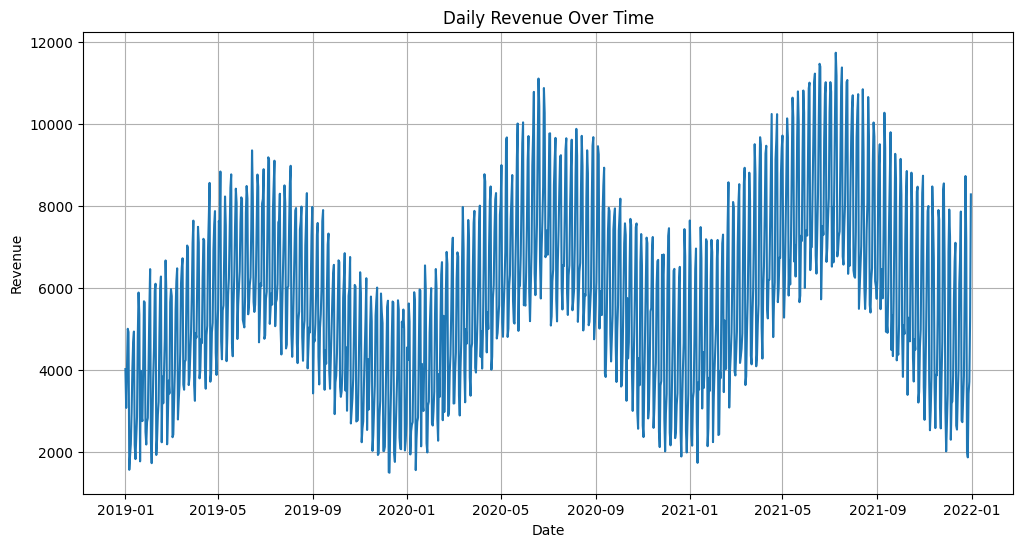

In [ ]:
#EDA
daily_sales = df.groupby("date")["revenue"].sum().reset_index()
print(daily_sales.head())

plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_sales, x='date', y='revenue')
plt.title('Daily Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()



<bound method NDFrame.head of day_of_week
Monday       41.333331
Tuesday      46.789711
Wednesday    51.758810
Thursday     68.377995
Friday       80.085233
Saturday     80.165021
Sunday       40.402546
Name: revenue, dtype: float64>


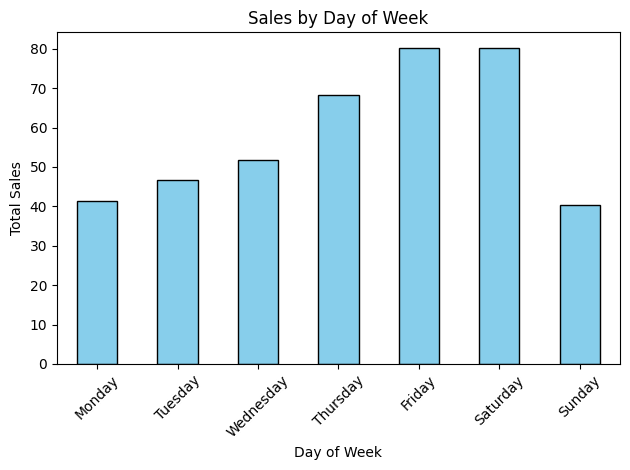

In [ ]:
#mean sales by day of week
df["day_of_week"] = df["date"].dt.day_name()
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_sales = df.groupby("day_of_week")["revenue"].mean().reindex(days_order)
print(weekday_sales.head)
weekday_sales.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<bound method NDFrame.head of month
January      40.406239
February     46.414986
March        53.571924
April        63.495377
May          71.619696
June         76.790673
July         75.918149
August       69.572577
September    60.991932
October      53.902388
November     45.837318
December     42.016916
Name: revenue, dtype: float64>


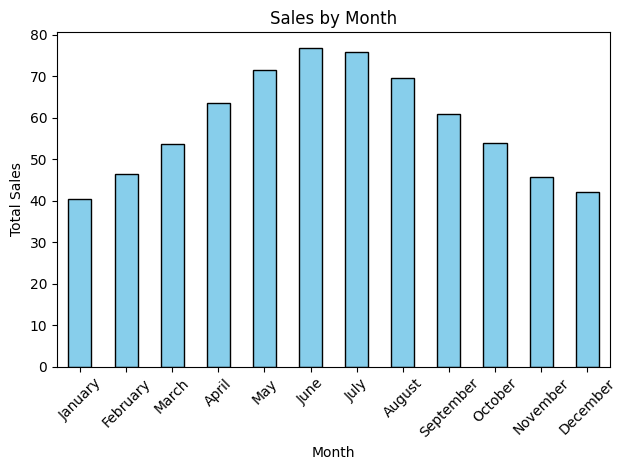

In [ ]:
#mean monthly sales
df["month"] = df["date"].dt.month_name()
months_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]
monthly_sales = df.groupby("month")["revenue"].mean().reindex(months_order)
print(monthly_sales.head)
monthly_sales.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Sales by Month")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

quarter
1    46.809014
2    70.646067
3    68.912723
4    47.267587
Name: revenue, dtype: float64


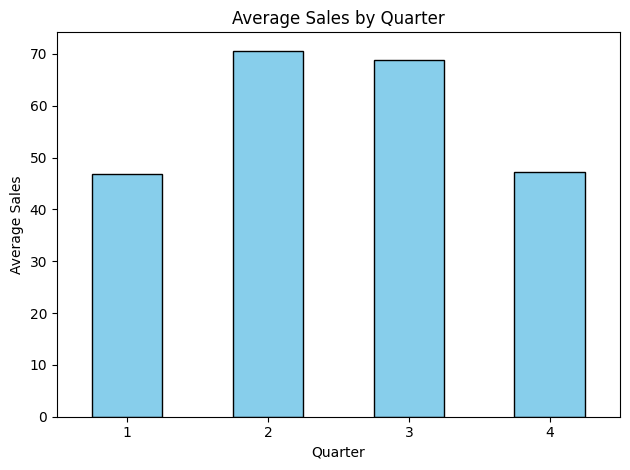

In [ ]:
#mean quareterly sales
df["quarter"] = df["date"].dt.quarter
quarterly_sales = df.groupby("quarter")["revenue"].mean()
quarterly_sales = quarterly_sales.reindex([1, 2, 3, 4])
print(quarterly_sales)
quarterly_sales.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Average Sales by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Average Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
#total sales by restraunt
restaurant_sales = df.groupby("store_name")["revenue"].sum().sort_values(ascending=False)
print("Total sales by restaurant:")
print(restaurant_sales)


Total sales by restaurant:
store_name
Bob's Diner       6337275.69
Fou Cher            27885.37
Corner Cafe         16551.43
Surfs Up            15651.49
Beachfront Bar       3796.20
Sweet Shack          2578.27
Name: revenue, dtype: float64


In [ ]:
#restraunt sales by year
df["year"] = df["date"].dt.year
sales_by_year = df.groupby(["store_name", "year"])["revenue"].sum()
print("\nSales by restaurant and year:")
print(sales_by_year)


Sales by restaurant and year:
store_name      year
Beachfront Bar  2019       1281.85
                2020       1267.21
                2021       1247.14
Bob's Diner     2019    1849483.49
                2020    2112331.91
                2021    2375460.29
Corner Cafe     2019       5292.93
                2020       5347.71
                2021       5910.79
Fou Cher        2019       9698.80
                2020       8590.87
                2021       9595.70
Surfs Up        2019       5132.65
                2020       5314.43
                2021       5204.41
Sweet Shack     2019        872.59
                2020        828.65
                2021        877.03
Name: revenue, dtype: float64


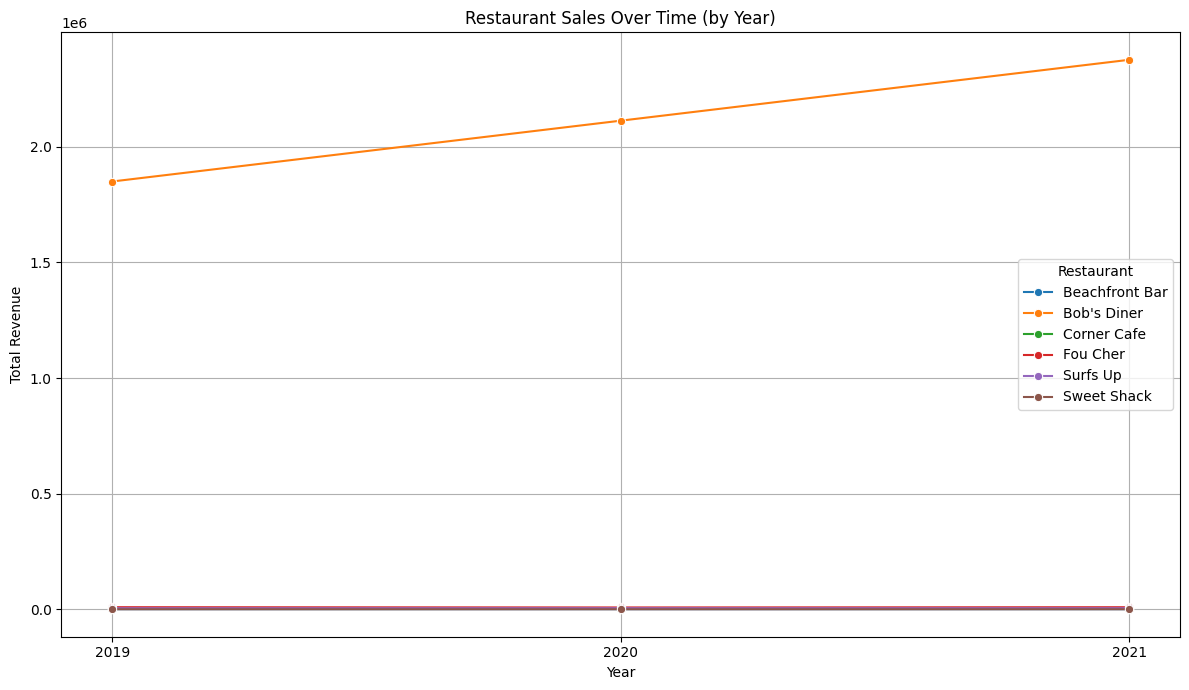

In [ ]:
#plotting restraunt sales by year
sales_by_year_df = sales_by_year.reset_index()
plt.figure(figsize=(12, 7))
sns.lineplot(data=sales_by_year_df, x='year', y='revenue', hue='store_name', marker='o')
plt.title('Restaurant Sales Over Time (by Year)')
plt.xlabel('Year')
plt.ylabel('Total Revenue')
plt.xticks(sales_by_year_df['year'].unique())
plt.grid(True)
plt.legend(title='Restaurant')
plt.tight_layout()
plt.show()


In [ ]:
#restraunt sales over day of week
daily_sales_by_restaurant = df.groupby(['store_name', 'day_of_week'])['revenue'].sum().reset_index()
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily_sales_by_restaurant['day_of_week'] = pd.Categorical(daily_sales_by_restaurant['day_of_week'], categories=days_order, ordered=True)
daily_sales_by_restaurant = daily_sales_by_restaurant.sort_values('day_of_week')
print(weekday_sales)
print("\nSales for each restaurant by day of week:")
display(daily_sales_by_restaurant)

day_of_week
Monday       41.333331
Tuesday      46.789711
Wednesday    51.758810
Thursday     68.377995
Friday       80.085233
Saturday     80.165021
Sunday       40.402546
Name: revenue, dtype: float64

Sales for each restaurant by day of week:


,store_name,day_of_week,revenue
1,Beachfront Bar,Monday,544.78
36,Sweet Shack,Monday,363.86
29,Surfs Up,Monday,2402.87
8,Bob's Diner,Monday,635165.98
22,Fou Cher,Monday,3927.47
15,Corner Cafe,Monday,2395.01
33,Surfs Up,Tuesday,1970.81
5,Beachfront Bar,Tuesday,548.72
26,Fou Cher,Tuesday,3742.68
40,Sweet Shack,Tuesday,405.07


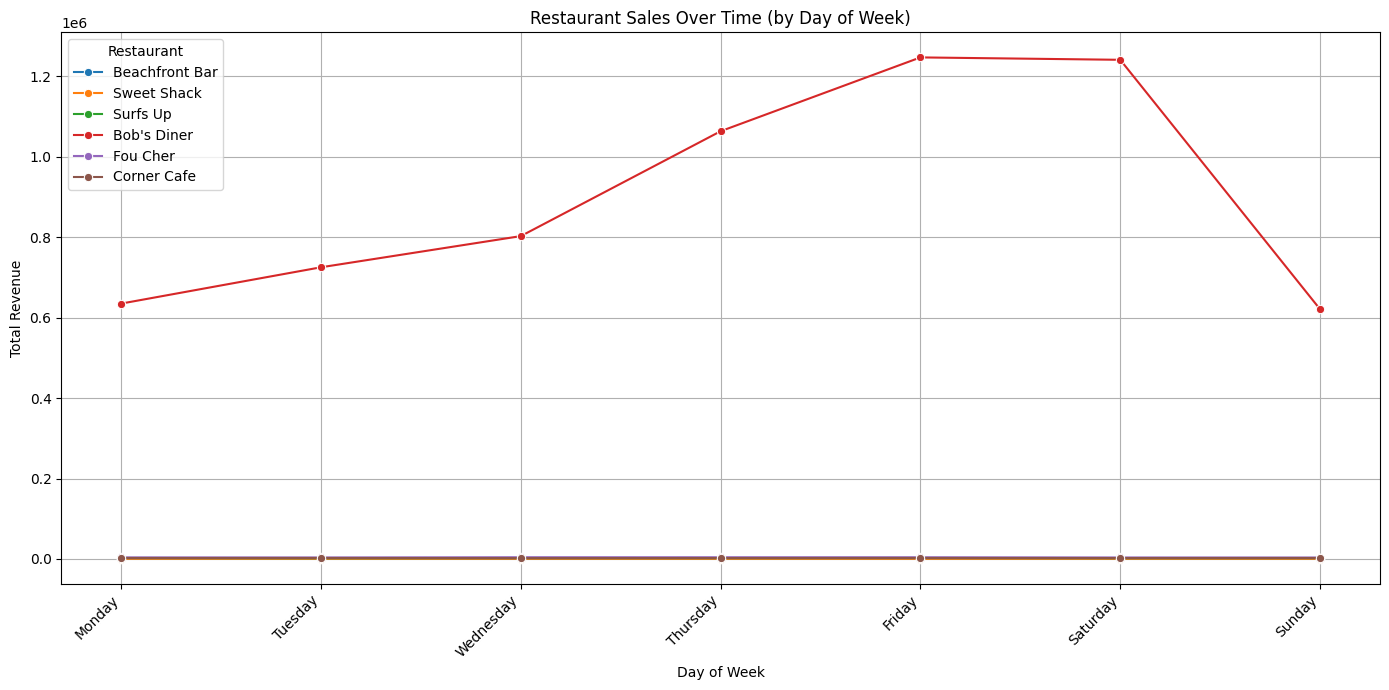

In [ ]:
#plotting Restaurant Sales Over Time by Day of Week
plt.figure(figsize=(14, 7))
sns.lineplot(data=daily_sales_by_restaurant, x='day_of_week', y='revenue', hue='store_name', marker='o')
plt.title('Restaurant Sales Over Time (by Day of Week)')
plt.xlabel('Day of Week')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.legend(title='Restaurant')
plt.tight_layout()
plt.show()

In [ ]:
#restraunt sales by month
monthly_sales_by_restaurant = df.groupby(['store_name', 'month'])['revenue'].sum().reset_index()
months_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]
monthly_sales_by_restaurant['month'] = pd.Categorical(monthly_sales_by_restaurant['month'], categories=months_order, ordered=True)
monthly_sales_by_restaurant = monthly_sales_by_restaurant.sort_values('month')
print("\nSales for each restaurant by month:")
display(monthly_sales_by_restaurant)



Sales for each restaurant by month:


,store_name,month,revenue
52,Surfs Up,January,1210.82
64,Sweet Shack,January,254.40
4,Beachfront Bar,January,315.55
28,Corner Cafe,January,1055.98
40,Fou Cher,January,2843.70
...,...,...,...
62,Sweet Shack,December,209.44
38,Fou Cher,December,2431.03
26,Corner Cafe,December,1354.65
14,Bob's Diner,December,385124.24


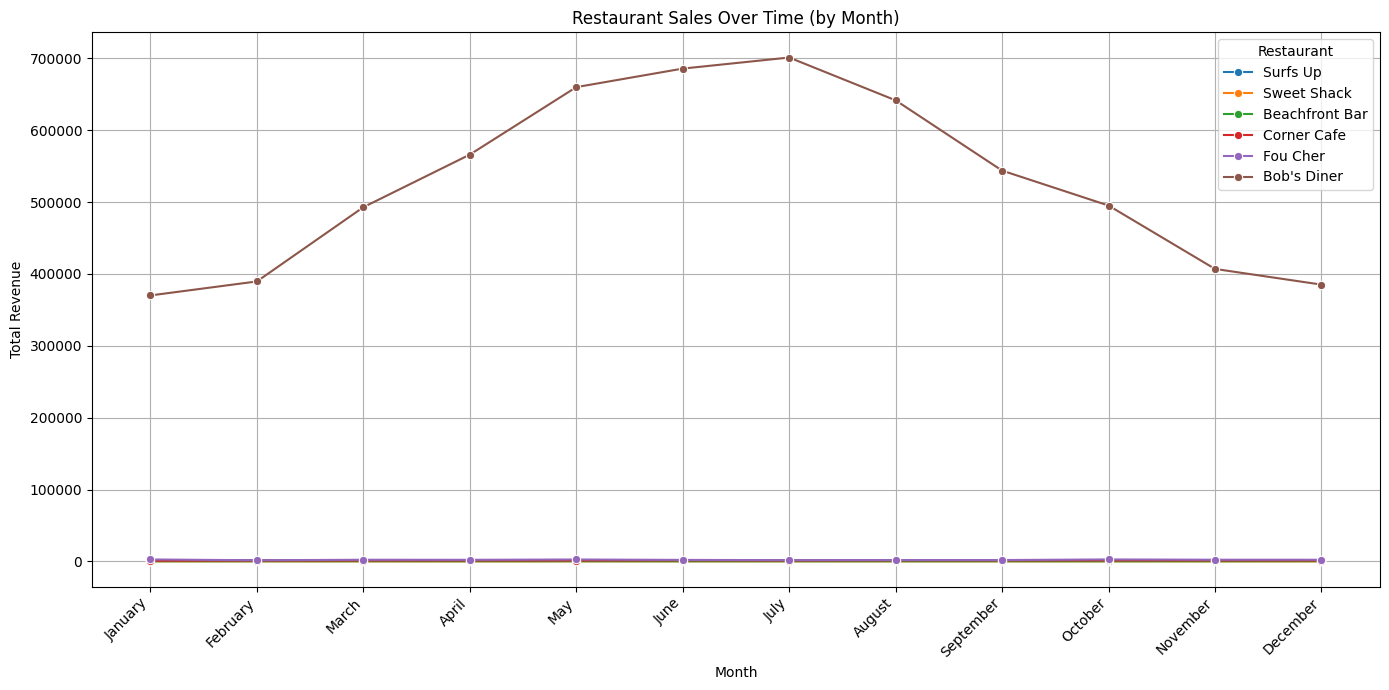

In [ ]:
# plotting restraunt sales by month
plt.figure(figsize=(14, 7))
sns.lineplot(data=monthly_sales_by_restaurant, x='month', y='revenue', hue='store_name', marker='o')
plt.title('Restaurant Sales Over Time (by Month)')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.legend(title='Restaurant')
plt.tight_layout()
plt.show()





In [ ]:
#MACHINE LEARNING
# 1. Most Popular Items Overall and the Stores where they are sold
overall_item_popularity = df.groupby(['item_name', 'store_name'])['item_count'].sum().reset_index()
overall_item_popularity = overall_item_popularity.groupby('item_name')['item_count'].sum().sort_values(ascending=False).reset_index()

print("\n--- Most Popular Items Overall ---")
display(overall_item_popularity.head(10))

# Get stores for the top overall items
top_n = 5
top_overall_items = overall_item_popularity.head(top_n)['item_name'].tolist()

print(f"\n--- Stores selling the top {top_n} overall popular items ---")
for item in top_overall_items:
    stores_selling_item = df[df['item_name'] == item]['store_name'].unique()
    print(f"'{item}' is sold at: {', '.join(stores_selling_item)}")

# 2. Most Popular Item at Each Store
store_item_sales = df.groupby(['store_name', 'item_name'])['item_count'].sum().reset_index()

most_popular_item_per_store = store_item_sales.loc[store_item_sales.groupby('store_name')['item_count'].idxmax()]

print("\n--- Most Popular Item at Each Store ---")
display(most_popular_item_per_store[['store_name', 'item_name', 'item_count']])


--- Most Popular Items Overall ---


,item_name,item_count
0,Strawberry Smoothy,236337.0
1,Frozen Milky Smoothy,103263.0
2,Amazing pork lunch,61043.0
3,Mutton Dinner,52772.0
4,Orange Juice,43874.0
5,Blue Ribbon Beef Entree,42774.0
6,Amazing Steak Dinner with Rolls,34439.0
7,Sweet Frozen Soft Drink,27490.0
8,Sea Bass with Vegetables Dinner,23839.0
9,Sweet Lamb Cake,18764.0



--- Stores selling the top 5 overall popular items ---
'Strawberry Smoothy' is sold at: Bob's Diner
'Frozen Milky Smoothy' is sold at: Bob's Diner, Corner Cafe
'Amazing pork lunch' is sold at: Bob's Diner
'Mutton Dinner' is sold at: Bob's Diner
'Orange Juice' is sold at: Bob's Diner

--- Most Popular Item at Each Store ---


,store_name,item_name,item_count
1,Beachfront Bar,Fantastic Milky Smoothy,1147.0
25,Bob's Diner,Strawberry Smoothy,236337.0
40,Corner Cafe,Frozen Milky Smoothy,273.0
57,Fou Cher,Blue Ribbon Fruity Vegi Lunch,298.0
85,Surfs Up,Awesome Soft Drink,997.0
92,Sweet Shack,Awesome Smoothy,1692.0


In [ ]:
top_restaurant_total_sales = restaurant_sales.idxmax()
print(f"Restaurant with the highest total sales volume: {top_restaurant_total_sales}\n")

daily_revenue_per_store = df.groupby(['store_name', 'date'])['revenue'].sum().reset_index()
average_daily_revenue = daily_revenue_per_store.groupby('store_name')['revenue'].mean().sort_values(ascending=False)

print("Average daily revenue per restaurant:")
display(average_daily_revenue)

if average_daily_revenue.index[0] == top_restaurant_total_sales:
    print(f"\nYes, the restaurant with the highest total sales volume ({top_restaurant_total_sales}) is also making the most money per day.")
else:
    print(f"\nNo, the restaurant with the highest total sales volume ({top_restaurant_total_sales}) is not making the most money per day. The restaurant making the most money per day is {average_daily_revenue.index[0]}.")


Restaurant with the highest total sales volume: Bob's Diner

Average daily revenue per restaurant:


,revenue
store_name,
Bob's Diner,5782.185849
Fou Cher,25.442856
Corner Cafe,15.101670
Surfs Up,14.280557
Beachfront Bar,3.463686
Sweet Shack,2.352436



Yes, the restaurant with the highest total sales volume (Bob's Diner) is also making the most money per day.


In [ ]:
idx_max_price = df.groupby('store_name')['price'].idxmax()
most_expensive_item_per_store = df.loc[idx_max_price, ['store_name', 'item_name', 'price', 'kcal']]

print("\nMost Expensive Item and its Calorie Count at Each Store:")
display(most_expensive_item_per_store.reset_index(drop=True))


Most Expensive Item and its Calorie Count at Each Store:


,store_name,item_name,price,kcal
0,Beachfront Bar,Sweet Vegi Soft Drink,5.70,538
1,Bob's Diner,Sweet Fruity Cake,29.22,931
2,Corner Cafe,Pike Lunch,26.37,653
3,Fou Cher,Blue Ribbon Fruity Vegi Lunch,53.98,881
4,Surfs Up,Steak Meal,26.21,607
5,Sweet Shack,Blue Ribbon Frozen Milky Cake,7.70,636


In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# Generate day_of_month feature
df['day_of_month'] = df['date'].dt.day

# Define target and features
target = 'revenue'
features = ['kcal', 'year', 'quarter', 'day_of_month', 'item_name', 'store_name', 'day_of_week', 'month']

X = df[features]
y = df[target]

# Identify categorical and numerical features
categorical_features = ['item_name', 'store_name', 'day_of_week', 'month']
numerical_features = ['kcal', 'year', 'quarter', 'day_of_month']

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = StandardScaler() # Scale numerical features
categorical_transformer = OneHotEncoder(handle_unknown='ignore') # One-hot encode categorical features

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Time-based train-test split: last six months for testing
# Assuming df is sorted by date or will be sorted
df_sorted = df.sort_values(by='date').reset_index(drop=True)

# Calculate cutoff date for the last 6 months
cutoff_date = df_sorted['date'].max() - pd.DateOffset(months=6)

train_df = df_sorted[df_sorted['date'] <= cutoff_date]
test_df = df_sorted[df_sorted['date'] > cutoff_date]

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# Define models
models = {
    'Linear Regression': Pipeline(steps=[('preprocessor', preprocessor),
                                         ('regressor', LinearRegression())]),
    'Random Forest': Pipeline(steps=[('preprocessor', preprocessor),
                                     ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))]),
    'XGBoost': Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', XGBRegressor(random_state=42, n_jobs=-1, objective='reg:squarederror'))])
}

# Train and evaluate each model
results = {}
best_model = None
best_r2 = -np.inf

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluate model performance
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}
    print(f"{name} - R2 Score: {r2:.4f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}")
    print("-" * 30)

    if r2 > best_r2:
        best_r2 = r2
        best_model = model
        best_model_name = name

print("\n--- Model Comparison ---")
results_df = pd.DataFrame(results).T
print(results_df.sort_values(by='R2', ascending=False))

print(f"\nConclusion: The best performing model based on R-squared is {best_model_name}.")

# Forecasting for the next year using the best model
print(f"\n--- Forecasting for the next year (2022) using {best_model_name} ---")

# Generate future dates for the next year (e.g., 2022)
last_date = df['date'].max()
forecast_start_date = last_date + pd.DateOffset(days=1)
forecast_end_date = forecast_start_date + pd.DateOffset(years=1) - pd.DateOffset(days=1)

future_dates = pd.date_range(start=forecast_start_date, end=forecast_end_date, freq='D')

# Get unique item_name and store_name combinations
unique_items_stores = df[['item_name', 'store_name']].drop_duplicates()

# Create a DataFrame for forecasting
forecast_data = []
for date in future_dates:
    for _, row in unique_items_stores.iterrows():
        forecast_data.append({
            'date': date,
            'item_name': row['item_name'],
            'store_name': row['store_name']
        })

forecast_df = pd.DataFrame(forecast_data)

# Add time-based features
forecast_df['year'] = forecast_df['date'].dt.year
forecast_df['month'] = forecast_df['date'].dt.month_name()
forecast_df['quarter'] = forecast_df['date'].dt.quarter
forecast_df['day_of_week'] = forecast_df['date'].dt.day_name()
forecast_df['day_of_month'] = forecast_df['date'].dt.day

# Merge with original df to get average kcal for each item_name
avg_kcal_per_item = df.groupby('item_name')['kcal'].mean().reset_index()
forecast_df = pd.merge(forecast_df, avg_kcal_per_item, on='item_name', how='left')

# Prepare X for forecasting
X_forecast = forecast_df[features]

# Make predictions
forecast_df['predicted_revenue'] = best_model.predict(X_forecast)

print("\nFirst 10 rows of the forecasted revenue for the next year:")
display(forecast_df.head(10))

Training data shape: (91200, 8)
Testing data shape: (18400, 8)

Training Linear Regression...
Linear Regression - R2 Score: 0.7277, RMSE: 123.86, MAE: 47.86
------------------------------

Training Random Forest...
Random Forest - R2 Score: 0.9249, RMSE: 65.06, MAE: 15.68
------------------------------

Training XGBoost...
XGBoost - R2 Score: 0.8823, RMSE: 81.45, MAE: 20.39
------------------------------

--- Model Comparison ---
                            MSE        RMSE        MAE        R2
Random Forest       4232.851066   65.060365  15.681989  0.924879
XGBoost             6633.335041   81.445289  20.391988  0.882277
Linear Regression  15340.674387  123.857476  47.855649  0.727746

Conclusion: The best performing model based on R-squared is Random Forest.

--- Forecasting for the next year (2022) using Random Forest ---

First 10 rows of the forecasted revenue for the next year:


,date,item_name,store_name,year,month,quarter,day_of_week,day_of_month,kcal,predicted_revenue
0,2022-01-01,Sweet Fruity Cake,Bob's Diner,2022,January,1,Saturday,1,931.0,48.5052
1,2022-01-01,Amazing Steak Dinner with Rolls,Bob's Diner,2022,January,1,Saturday,1,763.0,735.2686
2,2022-01-01,Fantastic Sweet Cola,Bob's Diner,2022,January,1,Saturday,1,478.0,20.9410
3,2022-01-01,Sweet Frozen Soft Drink,Bob's Diner,2022,January,1,Saturday,1,490.0,141.7810
4,2022-01-01,Frozen Milky Smoothy,Bob's Diner,2022,January,1,Saturday,1,247.5,74.4504
5,2022-01-01,Strawberry Smoothy,Bob's Diner,2022,January,1,Saturday,1,145.0,725.0721
6,2022-01-01,Amazing Fish with Vegetables Meal,Bob's Diner,2022,January,1,Saturday,1,269.0,303.8484
7,2022-01-01,Awesome Sweet Lamb Cake,Bob's Diner,2022,January,1,Saturday,1,671.0,13.3578
8,2022-01-01,Steak Meal,Surfs Up,2022,January,1,Saturday,1,607.0,14.4155
9,2022-01-01,Blue Ribbon Cocktail,Surfs Up,2022,January,1,Saturday,1,456.0,0.4360
